<a href="https://colab.research.google.com/github/manubastidas/programacionCientifica/blob/eval2-MarulandaDur%C3%A1n/Evaluacion2/MarulandaDur%C3%A1n/solucion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [61]:
##Inicialización de LaTeX

!sudo apt-get update
!sudo apt-get install texlive-latex-extra texlive-fonts-recommended dvipng cm-super
!pip install -q jax jaxlib optax

import numpy as np

from scipy.special import comb
from scipy.interpolate import CubicSpline, make_interp_spline

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 14,

    # Ejes y Ticks
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.direction": "in",
    "ytick.direction": "in",

    # Grid
    "grid.color"    : "gray",
    "grid.linewidth": 0.3,
    "grid.alpha"    : 0.3,
    "grid.linestyle": "--",

    # Estética
    "figure.dpi"        : 120,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "savefig.bbox"      : "tight",
    "savefig.dpi"       : 300,
})

print('Configuración OK')

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://cli.github.com/packages stable InRelease
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
cm-super is already the newest version (0.3.4-17).
dvipng is already the newest version (1.15-

In [62]:
import numpy as np
import jax.numpy as jnp
import jax
from jax import random
import matplotlib.pyplot as plt

# Carga de datos
datos = np.load('datos_6098.npz')
X = datos['X'] # Forma: (30, 256)
y = datos['y'] # Forma: (30,) con etiquetas de régimen 0, 1, 2
t = datos['t'] # Forma: (256,)

# Extraemos una señal por régimen para visualizaciones futuras
X_reg0 = X[y == 0]
X_reg1 = X[y == 1]
X_reg2 = X[y == 2]

# **1. Capa de Fourirer**

In [63]:
def construir_capa_fourier(t, K=25):
    """Construye la matriz W1 con filas de senos y cosenos."""
    # La matriz debe transformar de 256 a 50 (2K)
    W1 = np.zeros((2 * K, len(t)))

    # Asumimos que t va de 0 a un periodo T. Si t está normalizado entre 0 y 1:
    T = t[-1] - t[0] + (t[1] - t[0])

    for k in range(1, K + 1):
        # Frecuencias k
        W1[2*(k-1), :] = np.cos(2 * np.pi * k * t / T)
        W1[2*(k-1)+1, :] = np.sin(2 * np.pi * k * t / T)

    return jnp.array(W1)

W1_fourier = construir_capa_fourier(t, K=25)

# Evidencia de comparación con np.fft
x_prueba = X[0]
w1_out = W1_fourier @ x_prueba
fft_out = np.fft.fft(x_prueba)

# Reporte de la energía media del dataset
energia_media = (X**2).mean()
print(f"Energía media del dataset: {energia_media:.3f}")

Energía media del dataset: 0.786


Las entradas de np.fft son señales temporales, y las salidas son coeficientes complejos en el dominio de la frecuencia.

En este caso se hace con una sola señal para verificar la inicialización de $W_1$.

Reportamos la energía media establecer un umbral base que usaremos en la sección de compresión

# 2. Entrenamiento y reconstrucción

In [64]:
# Arquitectura de la red neuronal
def predecir(params, X_batch):
    W1, W2 = params
    # X_batch tiene forma (N, 256), la red procesa por filas
    return jnp.dot(jnp.tanh(jnp.dot(X_batch, W1.T)), W2.T)

# Función de pérdida (Error Cuadrático Medio)
def loss_fn(params, X_batch):
    X_hat = predecir(params, X_batch)
    return jnp.mean((X_hat - X_batch)**2)

# Función de actualización con descenso de gradiente
@jax.jit
def update(params, X_batch, lr=0.1):
    loss, grads = jax.value_and_grad(loss_fn)(params, X_batch)
    new_params = [p - lr * g for p, g in zip(params, grads)]
    return new_params, loss

# Inicialización de parámetros
key = random.PRNGKey(42)
key_w1, key_w2_f, key_w2_r = random.split(key, 3)

# Inicialización 1: Aleatoria
W1_random = random.normal(key_w1, (50, 256)) * 0.1
W2_random = random.normal(key_w2_r, (256, 50)) * 0.1
params_random = [W1_random, W2_random]

# Inicialización 2: Fourier
W2_fourier = random.normal(key_w2_f, (256, 50)) * 0.1
params_fourier = [W1_fourier, W2_fourier]

# Entrenamiento
iteraciones = 3000
loss_hist_random = []
loss_hist_fourier = []

for i in range(iteraciones):
    # Entrenamos con la inicialización aleatoria
    params_random, loss_r = update(params_random, X)
    loss_hist_random.append(loss_r)

    # Entrenamos con la inicialización de Fourier
    params_fourier, loss_f = update(params_fourier, X)
    loss_hist_fourier.append(loss_f)

Error de reconstrucción relativo (Inicialización Aleatoria): 0.2106
Error de reconstrucción relativo (Inicialización Fourier): 0.2538


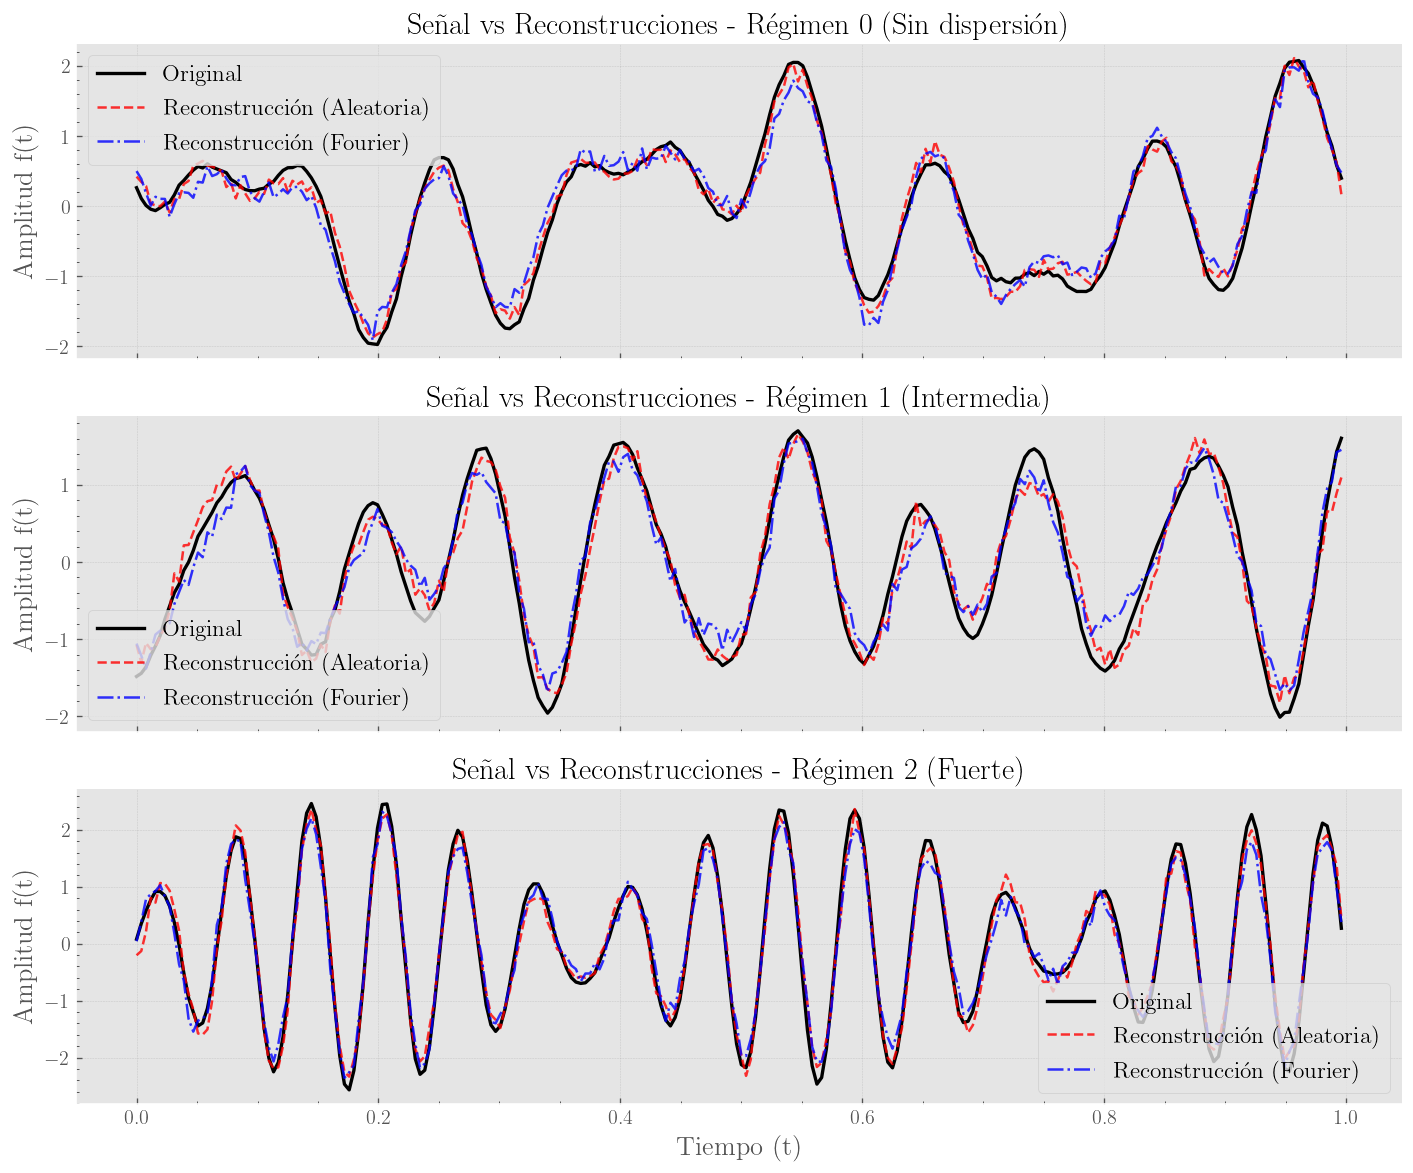

In [65]:
# Definir la función de error relativo solicitada
def calcular_error_relativo(x_real, x_pred):
    """Calcula |x_hat - x| / |x| para un conjunto de señales."""
    # Se utiliza la norma L2 (por defecto en jnp.linalg.norm)
    return jnp.linalg.norm(x_pred - x_real) / jnp.linalg.norm(x_real)

# Obtener las predicciones finales con ambas redes entrenadas
# params_random y params_fourier provienen del bucle de entrenamiento de 3000 iteraciones
X_hat_random = predecir(params_random, X)
X_hat_fourier = predecir(params_fourier, X)

# 3. Reportar el error de reconstrucción relativo global para cada caso
error_rel_random = calcular_error_relativo(X, X_hat_random)
error_rel_fourier = calcular_error_relativo(X, X_hat_fourier)

print(f"Error de reconstrucción relativo (Inicialización Aleatoria): {error_rel_random:.4f}")
print(f"Error de reconstrucción relativo (Inicialización Fourier): {error_rel_fourier:.4f}")

# 4. Preparar las gráficas: una señal de cada régimen
# Buscamos los índices de la primera señal de cada régimen en el vector 'y'
idx_reg0 = jnp.where(y == 0)[0][0]
idx_reg1 = jnp.where(y == 1)[0][0]
idx_reg2 = jnp.where(y == 2)[0][0]

indices = [idx_reg0, idx_reg1, idx_reg2]
titulos = ['Régimen 0 (Sin dispersión)', 'Régimen 1 (Intermedia)', 'Régimen 2 (Fuerte)']

fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

for i, (idx, titulo) in enumerate(zip(indices, titulos)):
    # Señal original
    axs[i].plot(t, X[idx], label='Original', color='black', linewidth=2)

    # Reconstrucción red aleatoria
    axs[i].plot(t, X_hat_random[idx], label='Reconstrucción (Aleatoria)',
                color='red', linestyle='--', alpha=0.8)

    # Reconstrucción red Fourier
    axs[i].plot(t, X_hat_fourier[idx], label='Reconstrucción (Fourier)',
                color='blue', linestyle='-.', alpha=0.8)

    axs[i].set_title(f'Señal vs Reconstrucciones - {titulo}')
    axs[i].set_ylabel('Amplitud f(t)')
    axs[i].legend()
    axs[i].grid(True, alpha=0.3)

axs[-1].set_xlabel('Tiempo (t)')
plt.tight_layout()
plt.show()

Debe ser un dato con el que se entrenó la red, pues no estamos midiendo si la red puede predecir señales nuevas, sino comparando qué tan bien aprende cada inicialización a reconstruir la misma información.

La diferencia está en que entre más pequeño sea nuestro número de iteraciones mejor aproxima la reconstrución aleatoria, es decir su error relativo es menor, y en cuanto más crece el número de iteraciones, la de Fourier es más preciso. Esto debido a que por la naturaleza del problema, Fourier se aproximará muy bien en cuanto tenga suficiente información, sin embargo, con pocas iteraciones, las ondas sinusoidales pueden no aproximar muy bien.